# Hybrid Machine Learning Model - Voting Classifier
## Combining Decision Tree & Random Forest for Phishing Detection

This notebook creates a **hybrid model** using a **Voting Classifier** that combines:
1. **Decision Tree Classifier** (from Phishing_DT.ipynb)
2. **Random Forest Classifier** (from Phishing_Random_Forests.ipynb)

The model is trained using **all 41 features** from the dataset to maximise detection accuracy
and reduce false positives (legitimate URLs incorrectly flagged as phishing).

**Voting Strategies:**
- **Hard Voting** – Each model votes for a class; the majority wins.
- **Soft Voting** – Each model outputs class probabilities; the class with the highest average probability wins.

## Step 1: Install & Import Libraries

In [1]:
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    matthews_corrcoef, ConfusionMatrixDisplay, roc_curve, auc
)
import joblib
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load & Preprocess the Dataset

In [3]:
# Load dataset (same dataset used in both original notebooks)
df_phishing_csv = pd.read_csv('datasets/Dataset.csv', on_bad_lines='skip')
print(f"Original dataset shape: {df_phishing_csv.shape}")
print(f"Has NaN values: {df_phishing_csv.isnull().values.any()}")

Original dataset shape: (247950, 42)
Has NaN values: False


In [4]:
# Clean dataset - remove any rows with missing values
cleaned_df = df_phishing_csv.dropna(how='any')
print(f"Cleaned dataset shape: {cleaned_df.shape}")
print(f"\nClass distribution (0=Legitimate, 1=Phishing):")
print(cleaned_df['Type'].value_counts())

Cleaned dataset shape: (247950, 42)

Class distribution (0=Legitimate, 1=Phishing):
Type
0    128541
1    119409
Name: count, dtype: int64


In [5]:
# Preview dataset
cleaned_df.head()

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
0,0,37,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,4.010412,2.751629
1,1,70,5,0,0,12,0,0,6,0,...,0,0,1,0,4,0,0,0,4.089470,3.532573
2,0,42,2,0,6,8,0,0,3,1,...,0,0,1,0,1,1,0,0,4.386016,3.344698
3,0,46,2,0,0,7,0,0,4,0,...,0,0,1,0,2,0,0,0,4.221947,3.189898
4,0,51,3,0,0,9,0,0,5,0,...,0,0,1,0,3,0,0,0,4.103538,2.952820


In [6]:
cleaned_df.describe()

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
count,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,...,247950.000000,247950.000000,247950.0,247950.0,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000
mean,0.481585,58.358197,2.894075,0.162351,4.366070,10.303218,0.600867,0.204049,4.784533,0.159911,...,0.064529,0.224013,1.0,0.0,2.606977,0.126501,0.002303,0.000944,4.257222,3.389839
std,0.499662,29.764620,1.690970,0.368773,9.579032,4.718381,1.235599,0.653502,1.812574,0.449506,...,0.245694,1.276447,0.0,0.0,1.636938,0.332414,0.047933,0.030706,0.328098,0.376361
min,0.000000,12.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,2.000000,0.000000,...,0.000000,0.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,2.648939,1.386274
25%,0.000000,39.000000,2.000000,0.000000,0.000000,7.000000,0.000000,0.000000,4.000000,0.000000,...,0.000000,0.000000,1.0,0.0,2.000000,0.000000,0.000000,0.000000,4.038910,3.180833
50%,0.000000,49.000000,3.000000,0.000000,0.000000,9.000000,0.000000,0.000000,4.000000,0.000000,...,0.000000,0.000000,1.0,0.0,2.000000,0.000000,0.000000,0.000000,4.208298,3.392747
75%,1.000000,69.000000,3.000000,0.000000,4.000000,11.000000,1.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.0,0.0,3.000000,0.000000,0.000000,0.000000,4.428036,3.606937
max,1.000000,191.000000,28.000000,1.000000,144.000000,75.000000,23.000000,47.000000,30.000000,17.000000,...,1.000000,44.000000,1.0,0.0,28.000000,1.000000,1.000000,1.000000,5.866327,4.957323


In [7]:
# Display all feature names (columns) in the dataset
feature_names = list(cleaned_df.columns[1:])  # All columns except 'Type'
print(f"Total number of features: {len(feature_names)}")
print(f"\nAll features used for training:")
for i, feat in enumerate(feature_names, 1):
    print(f"  {i:2d}. {feat}")

Total number of features: 41

All features used for training:
   1. url_length
   2. number_of_dots_in_url
   3. having_repeated_digits_in_url
   4. number_of_digits_in_url
   5. number_of_special_char_in_url
   6. number_of_hyphens_in_url
   7. number_of_underline_in_url
   8. number_of_slash_in_url
   9. number_of_questionmark_in_url
  10. number_of_equal_in_url
  11. number_of_at_in_url
  12. number_of_dollar_in_url
  13. number_of_exclamation_in_url
  14. number_of_hashtag_in_url
  15. number_of_percent_in_url
  16. domain_length
  17. number_of_dots_in_domain
  18. number_of_hyphens_in_domain
  19. having_special_characters_in_domain
  20. number_of_special_characters_in_domain
  21. having_digits_in_domain
  22. number_of_digits_in_domain
  23. having_repeated_digits_in_domain
  24. number_of_subdomains
  25. having_dot_in_subdomain
  26. having_hyphen_in_subdomain
  27. average_subdomain_length
  28. average_number_of_dots_in_subdomain
  29. average_number_of_hyphens_in_subdomai

In [8]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247950 entries, 0 to 247949
Data columns (total 42 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Type                                       247950 non-null  int64  
 1   url_length                                 247950 non-null  int64  
 2   number_of_dots_in_url                      247950 non-null  int64  
 3   having_repeated_digits_in_url              247950 non-null  int64  
 4   number_of_digits_in_url                    247950 non-null  int64  
 5   number_of_special_char_in_url              247950 non-null  int64  
 6   number_of_hyphens_in_url                   247950 non-null  int64  
 7   number_of_underline_in_url                 247950 non-null  int64  
 8   number_of_slash_in_url                     247950 non-null  int64  
 9   number_of_questionmark_in_url              247950 non-null  int64  
 10  number_o

In [9]:
# Check for missing values
print(cleaned_df.isnull().sum())

Type                                         0
url_length                                   0
number_of_dots_in_url                        0
having_repeated_digits_in_url                0
number_of_digits_in_url                      0
number_of_special_char_in_url                0
number_of_hyphens_in_url                     0
number_of_underline_in_url                   0
number_of_slash_in_url                       0
number_of_questionmark_in_url                0
number_of_equal_in_url                       0
number_of_at_in_url                          0
number_of_dollar_in_url                      0
number_of_exclamation_in_url                 0
number_of_hashtag_in_url                     0
number_of_percent_in_url                     0
domain_length                                0
number_of_dots_in_domain                     0
number_of_hyphens_in_domain                  0
having_special_characters_in_domain          0
number_of_special_characters_in_domain       0
having_digits

In [10]:
# Distribution of target variable
print(cleaned_df['Type'].value_counts())

Type
0    128541
1    119409
Name: count, dtype: int64


## Step 3: Feature Selection (All 41 Features) & Train-Test Split

Using **all 41 features** from the dataset to give the hybrid model the richest possible signal for accurate phishing detection.

In [11]:
# Feature selection - use ALL features (same as original DT and RF notebooks)
X = cleaned_df.iloc[:, 1:].values  # All features except the first column (Type)
y = cleaned_df.iloc[:, 0].values   # Target variable (Type: 0=Legitimate, 1=Phishing)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (247950, 41)
Target shape: (247950,)


In [12]:
print(X)

[[37.          2.          0.         ...  0.          4.01041207
   2.75162917]
 [70.          5.          0.         ...  0.          4.08946998
   3.53257326]
 [42.          2.          0.         ...  0.          4.38601593
   3.34469838]
 ...
 [33.          2.          0.         ...  0.          3.81320653
   3.32781953]
 [83.          1.          1.         ...  0.          4.54017264
   3.375     ]
 [34.          3.          0.         ...  0.          4.0352735
   3.18200582]]


In [13]:
print(y)

[0 1 0 ... 1 1 0]


In [14]:
# Split dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 198360
Test set size: 49590


In [15]:
print(y_test)

[1 0 0 ... 0 1 1]


In [16]:
# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [17]:
print(X_train)

[[-0.71673412  0.06443234 -0.43984759 ... -0.03176925 -1.01029264
   0.3516678 ]
 [-0.64948196 -0.52960895 -0.43984759 ... -0.03176925 -0.22664633
  -0.39734445]
 [ 0.59468311  0.65847362 -0.43984759 ... -0.03176925  0.16695165
   0.81114976]
 ...
 [-0.51497763  0.65847362 -0.43984759 ... -0.03176925 -1.04452362
  -0.57043842]
 [-0.71673412  0.06443234 -0.43984759 ... -0.03176925 -0.54574376
  -0.96431227]
 [ 0.76281352 -0.52960895 -0.43984759 ... -0.03176925  1.23229164
   0.57769396]]


In [18]:
print(X_test)

[[ 2.64587416  0.65847362  2.2735148  ... -0.03176925  1.6723372
   0.61491624]
 [-0.21234288 -0.52960895 -0.43984759 ... -0.03176925 -0.14361757
   0.48605027]
 [-0.31322113 -0.52960895 -0.43984759 ... -0.03176925  0.01123972
  -0.04282964]
 ...
 [-0.85123846 -0.52960895  2.2735148  ... -0.03176925 -0.50964065
  -1.93068618]
 [ 0.35930053  0.06443234  2.2735148  ... -0.03176925  1.1550665
   0.70045473]
 [ 0.46017878 -0.52960895 -0.43984759 ... -0.03176925  0.11879561
   1.19216496]]


## Step 4: Build Individual Models (Base Estimators)
Building the same models used in the original notebooks with all 41 features, so we can compare them to the hybrid.

In [19]:
# Model 1: Decision Tree Classifier (same as Phishing_DT.ipynb)
dt_clf = DecisionTreeClassifier(random_state=0)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

print("=" * 60)
print("MODEL 1: DECISION TREE CLASSIFIER (All 41 Features)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.6f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.6f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.6f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_dt):.6f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_dt):.6f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

MODEL 1: DECISION TREE CLASSIFIER (All 41 Features)
Accuracy:  0.954305
Precision: 0.954272
Recall:    0.950510
F1-Score:  0.952387
ROC AUC:   0.954165
MCC:       0.908469

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     25747
           1       0.95      0.95      0.95     23843

    accuracy                           0.95     49590
   macro avg       0.95      0.95      0.95     49590
weighted avg       0.95      0.95      0.95     49590



In [20]:
# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix (Decision Tree):")
print(cm_dt)

Confusion Matrix (Decision Tree):
[[24661  1086]
 [ 1180 22663]]


In [21]:
# Model 2: Random Forest Classifier (same as Phishing_Random_Forests.ipynb)
rf_clf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("=" * 60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (All 41 Features)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.6f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.6f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.6f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_rf):.6f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_rf):.6f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

MODEL 2: RANDOM FOREST CLASSIFIER (All 41 Features)
Accuracy:  0.961404
Precision: 0.971652
Recall:    0.947364
F1-Score:  0.959354
ROC AUC:   0.960884
MCC:       0.922889

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     25747
           1       0.97      0.95      0.96     23843

    accuracy                           0.96     49590
   macro avg       0.96      0.96      0.96     49590
weighted avg       0.96      0.96      0.96     49590



In [22]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):")
print(cm_rf)

Confusion Matrix (Random Forest):
[[25088   659]
 [ 1255 22588]]


## Step 5: Build the Hybrid Voting Classifier

The **VotingClassifier** combines both models using two strategies:
- **Hard Voting**: Each classifier votes for a class label; the majority vote wins.
- **Soft Voting**: Each classifier outputs probability estimates; the class with the highest average probability wins.

In [23]:
# ==========================================
# HYBRID MODEL: HARD VOTING CLASSIFIER
# ==========================================
# Each model casts a vote, and the majority class wins

hard_voting_clf = VotingClassifier(
    estimators=[
        ('decision_tree', DecisionTreeClassifier(random_state=0)),
        ('random_forest', RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0))
    ],
    voting='hard'
)

hard_voting_clf.fit(X_train, y_train)
y_pred_hard = hard_voting_clf.predict(X_test)

print("=" * 60)
print("HYBRID MODEL: HARD VOTING CLASSIFIER (All 41 Features)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_hard):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_hard):.6f}")
print(f"Recall:    {recall_score(y_test, y_pred_hard):.6f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_hard):.6f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_hard):.6f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_hard):.6f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hard))

HYBRID MODEL: HARD VOTING CLASSIFIER (All 41 Features)
Accuracy:  0.957290
Precision: 0.980238
Recall:    0.929917
F1-Score:  0.954414
ROC AUC:   0.956278
MCC:       0.915414

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     25747
           1       0.98      0.93      0.95     23843

    accuracy                           0.96     49590
   macro avg       0.96      0.96      0.96     49590
weighted avg       0.96      0.96      0.96     49590



In [24]:
# Confusion Matrix for Hard Voting
cm_hard = confusion_matrix(y_test, y_pred_hard)
print("Confusion Matrix (Hard Voting):")
print(cm_hard)

Confusion Matrix (Hard Voting):
[[25300   447]
 [ 1671 22172]]


In [25]:
# ==========================================
# HYBRID MODEL: SOFT VOTING CLASSIFIER
# ==========================================
# Each model outputs class probabilities; the class with the highest average probability wins

soft_voting_clf = VotingClassifier(
    estimators=[
        ('decision_tree', DecisionTreeClassifier(random_state=0)),
        ('random_forest', RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0))
    ],
    voting='soft'
)

soft_voting_clf.fit(X_train, y_train)
y_pred_soft = soft_voting_clf.predict(X_test)

print("=" * 60)
print("HYBRID MODEL: SOFT VOTING CLASSIFIER (All 41 Features)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_soft):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_soft):.6f}")
print(f"Recall:    {recall_score(y_test, y_pred_soft):.6f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_soft):.6f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_soft):.6f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_soft):.6f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_soft))

HYBRID MODEL: SOFT VOTING CLASSIFIER (All 41 Features)
Accuracy:  0.955919
Precision: 0.957497
Recall:    0.950510
F1-Score:  0.953991
ROC AUC:   0.955719
MCC:       0.911706

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     25747
           1       0.96      0.95      0.95     23843

    accuracy                           0.96     49590
   macro avg       0.96      0.96      0.96     49590
weighted avg       0.96      0.96      0.96     49590



In [26]:
# Confusion Matrix for Soft Voting
cm_soft = confusion_matrix(y_test, y_pred_soft)
print("Confusion Matrix (Soft Voting):")
print(cm_soft)

Confusion Matrix (Soft Voting):
[[24741  1006]
 [ 1180 22663]]


## Step 6: Comparative Analysis - All Models

In [27]:
# Create a comprehensive comparison DataFrame
results = {
    'Model': ['Decision Tree', 'Random Forest', 'Hybrid (Hard Voting)', 'Hybrid (Soft Voting)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_hard),
        accuracy_score(y_test, y_pred_soft)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_hard),
        precision_score(y_test, y_pred_soft)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_hard),
        recall_score(y_test, y_pred_soft)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_hard),
        f1_score(y_test, y_pred_soft)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_hard),
        roc_auc_score(y_test, y_pred_soft)
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_dt),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_hard),
        matthews_corrcoef(y_test, y_pred_soft)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.round(6)
print("\n" + "=" * 90)
print("COMPREHENSIVE MODEL COMPARISON (All 41 Features)")
print("=" * 90)
results_df


COMPREHENSIVE MODEL COMPARISON (All 41 Features)


,Accuracy,Precision,Recall,F1-Score,ROC AUC,MCC
Model,,,,,,
Decision Tree,0.954305,0.954272,0.950510,0.952387,0.954165,0.908469
Random Forest,0.961404,0.971652,0.947364,0.959354,0.960884,0.922889
Hybrid (Hard Voting),0.957290,0.980238,0.929917,0.954414,0.956278,0.915414
Hybrid (Soft Voting),0.955919,0.957497,0.950510,0.953991,0.955719,0.911706


In [28]:
# Highlight the best model for each metric
print("\nBest model per metric:")
print("-" * 40)
for col in results_df.columns:
    best_model = results_df[col].idxmax()
    best_value = results_df[col].max()
    print(f"{col:12s}: {best_model} ({best_value:.6f})")


Best model per metric:
----------------------------------------
Accuracy    : Random Forest (0.961404)
Precision   : Hybrid (Hard Voting) (0.980238)
Recall      : Decision Tree (0.950510)
F1-Score    : Random Forest (0.959354)
ROC AUC     : Random Forest (0.960884)
MCC         : Random Forest (0.922889)


## Step 7: Visualisations

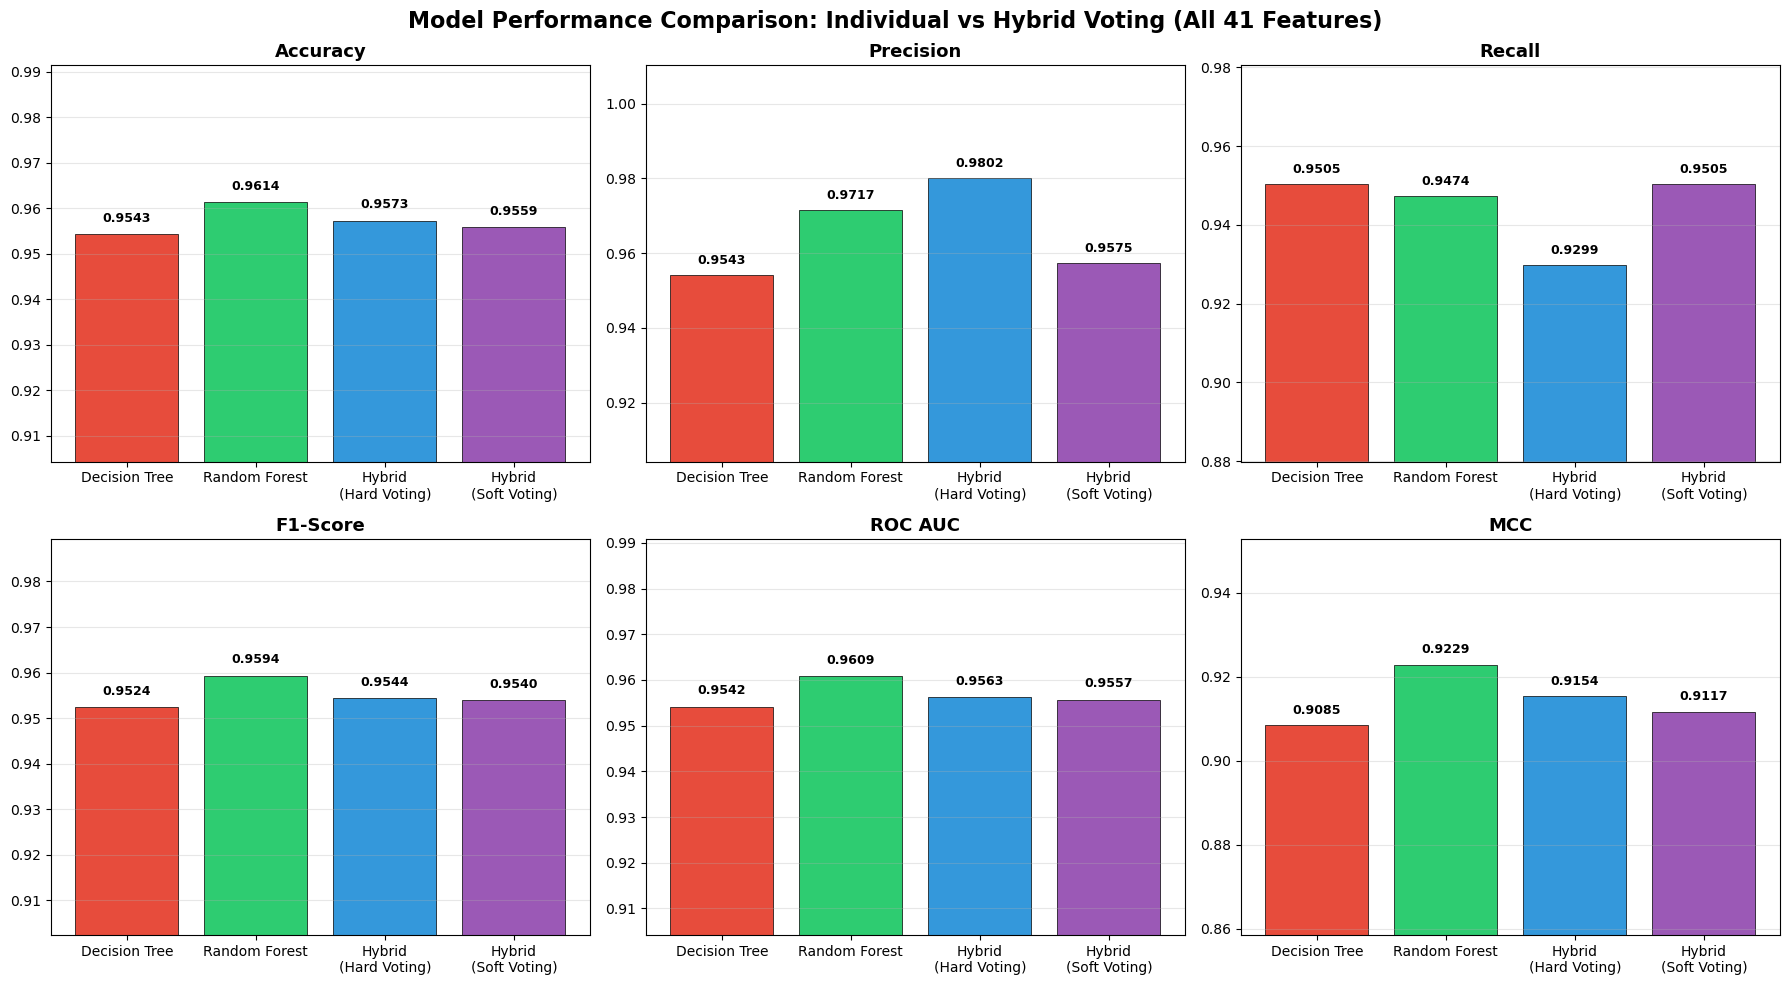

In [29]:
# Bar chart comparison of all models across all metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison: Individual vs Hybrid Voting (All 41 Features)', fontsize=16, fontweight='bold')

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'MCC']
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
model_names = ['Decision Tree', 'Random Forest', 'Hybrid\n(Hard Voting)', 'Hybrid\n(Soft Voting)']

for idx, metric in enumerate(metrics_list):
    ax = axes[idx // 3, idx % 3]
    values = results_df[metric].values
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(min(values) - 0.05, max(values) + 0.03)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

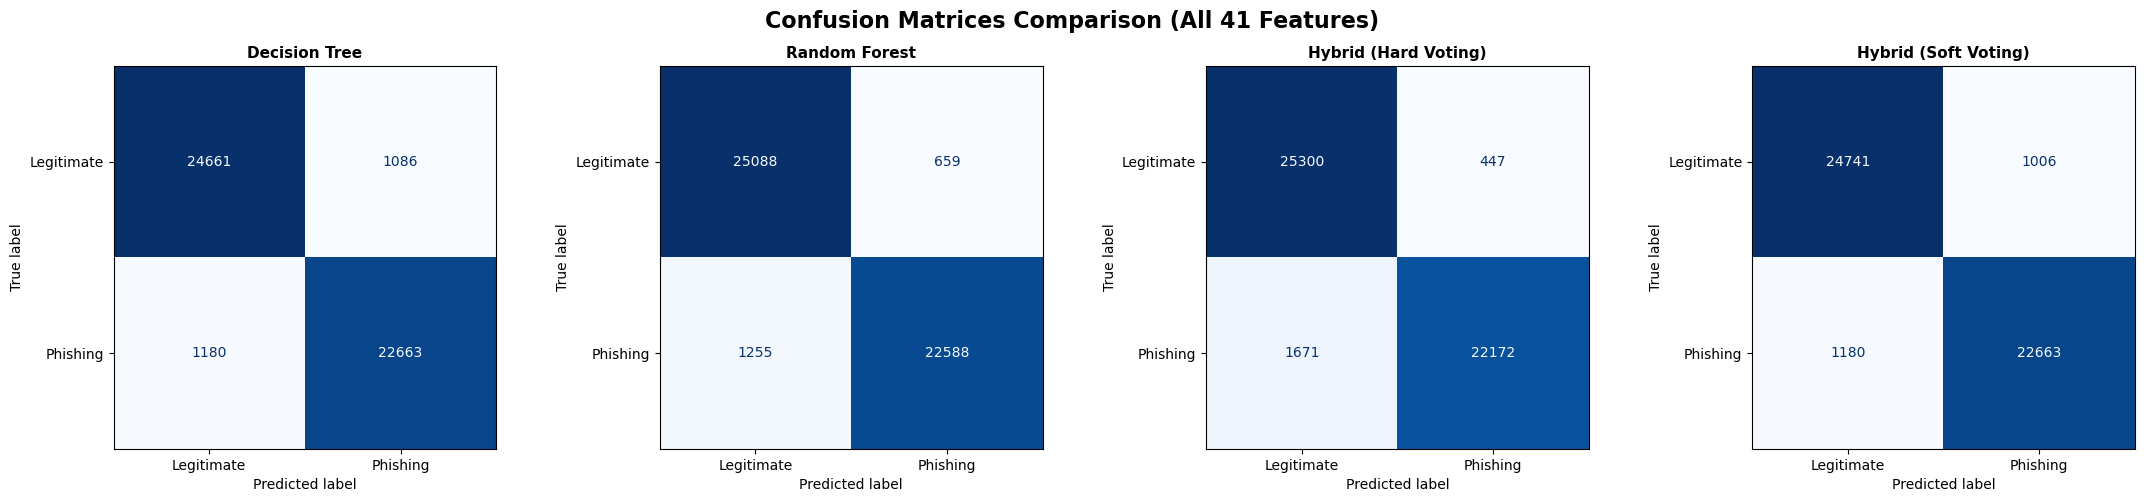

In [30]:
# Confusion Matrices side by side
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices Comparison (All 41 Features)', fontsize=16, fontweight='bold')

cms = [cm_dt, cm_rf, cm_hard, cm_soft]
titles = ['Decision Tree', 'Random Forest', 'Hybrid (Hard Voting)', 'Hybrid (Soft Voting)']

for ax, cm, title in zip(axes, cms, titles):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

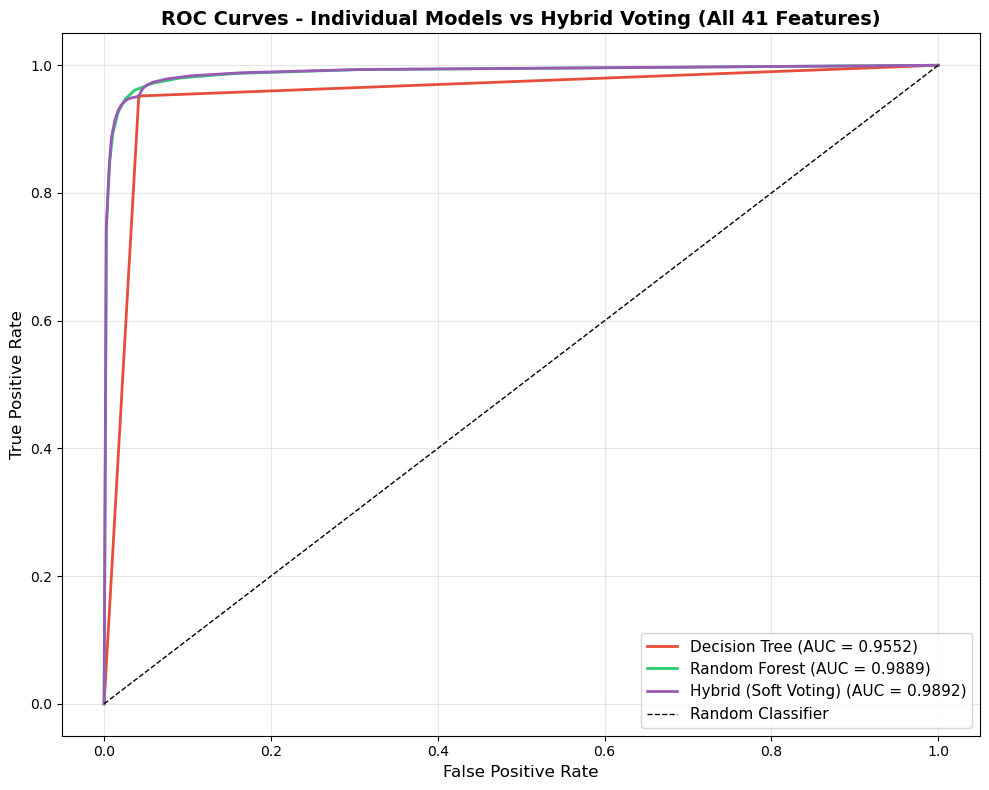

In [31]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

# Get probability scores for ROC curves
dt_proba = dt_clf.predict_proba(X_test)[:, 1]
rf_proba = rf_clf.predict_proba(X_test)[:, 1]
soft_proba = soft_voting_clf.predict_proba(X_test)[:, 1]

for name, proba, color in [
    ('Decision Tree', dt_proba, '#e74c3c'),
    ('Random Forest', rf_proba, '#2ecc71'),
    ('Hybrid (Soft Voting)', soft_proba, '#9b59b6')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Individual Models vs Hybrid Voting (All 41 Features)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

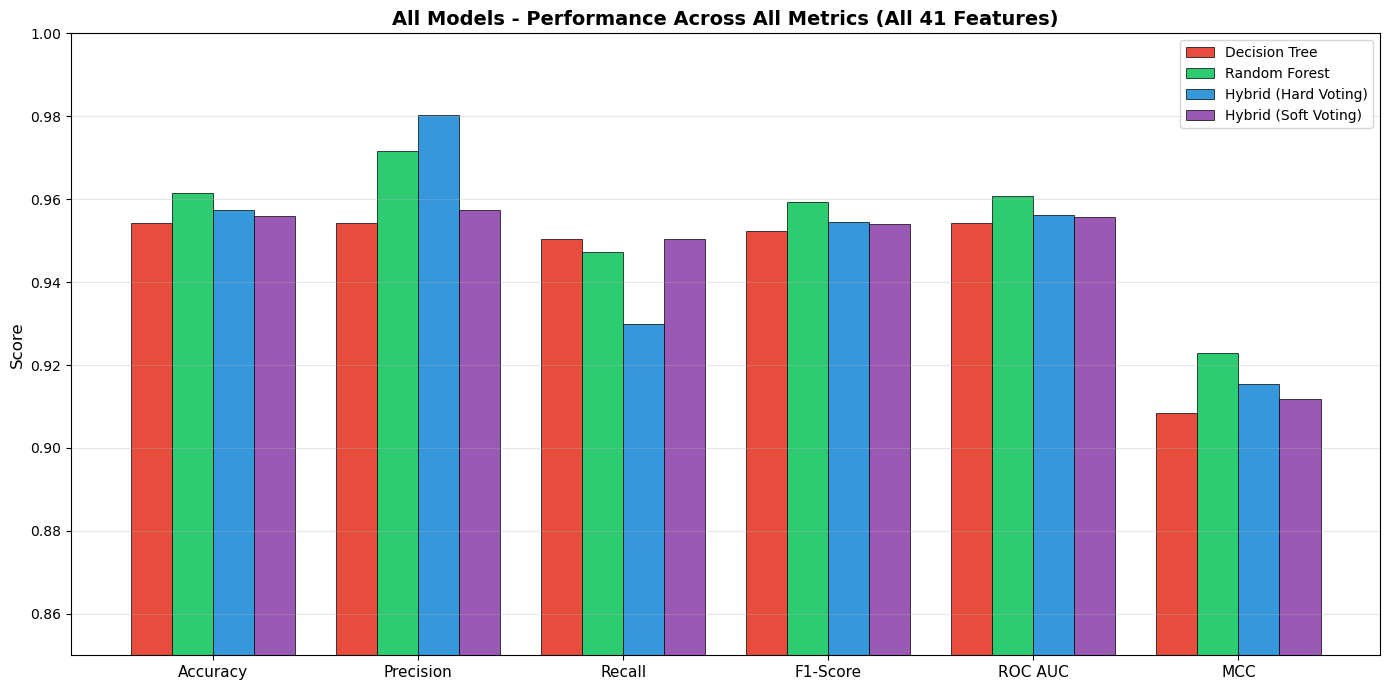

In [32]:
# Grouped bar chart - all metrics in one plot
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metrics_list))
width = 0.2

for i, (model, color) in enumerate(zip(results_df.index, colors)):
    values = results_df.loc[model].values
    bars = ax.bar(x + i * width, values, width, label=model, color=color, edgecolor='black', linewidth=0.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models - Performance Across All Metrics (All 41 Features)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.savefig('all_metrics_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Save Models & Feature Names for Django App

In [33]:
# Save the hybrid models and scaler for use in the Django application

joblib.dump(hard_voting_clf, 'phishing_hybrid_voting_hard.pkl')
joblib.dump(soft_voting_clf, 'phishing_hybrid_voting_soft.pkl')
joblib.dump(sc, 'standard_scaler.pkl')

# IMPORTANT: Save the feature names so the Django app knows the exact order
joblib.dump(feature_names, 'feature_names.pkl')

print("Models and artifacts saved successfully:")
print("  - phishing_hybrid_voting_hard.pkl  (Hard Voting model)")
print("  - phishing_hybrid_voting_soft.pkl   (Soft Voting model)")
print("  - standard_scaler.pkl               (StandardScaler fitted on training data)")
print("  - feature_names.pkl                 (List of 41 feature names in correct order)")
print(f"\nFeature order saved ({len(feature_names)} features):")
for i, feat in enumerate(feature_names, 1):
    print(f"  {i:2d}. {feat}")

Models and artifacts saved successfully:
  - phishing_hybrid_voting_hard.pkl  (Hard Voting model)
  - phishing_hybrid_voting_soft.pkl   (Soft Voting model)
  - standard_scaler.pkl               (StandardScaler fitted on training data)
  - feature_names.pkl                 (List of 41 feature names in correct order)

Feature order saved (41 features):
   1. url_length
   2. number_of_dots_in_url
   3. having_repeated_digits_in_url
   4. number_of_digits_in_url
   5. number_of_special_char_in_url
   6. number_of_hyphens_in_url
   7. number_of_underline_in_url
   8. number_of_slash_in_url
   9. number_of_questionmark_in_url
  10. number_of_equal_in_url
  11. number_of_at_in_url
  12. number_of_dollar_in_url
  13. number_of_exclamation_in_url
  14. number_of_hashtag_in_url
  15. number_of_percent_in_url
  16. domain_length
  17. number_of_dots_in_domain
  18. number_of_hyphens_in_domain
  19. having_special_characters_in_domain
  20. number_of_special_characters_in_domain
  21. having_digi

## Step 9: Summary & Conclusion

In [34]:
print("=" * 70)
print("SUMMARY: HYBRID VOTING CLASSIFIER RESULTS (All 41 Features)")
print("=" * 70)
print("\nModels Combined:")
print("  1. Decision Tree Classifier")
print("  2. Random Forest Classifier (n_estimators=10, criterion=entropy)")
print(f"\nTotal Features Used: {len(feature_names)}")
print("\nVoting Strategies Tested:")
print("  - Hard Voting: Majority vote from both classifiers")
print("  - Soft Voting: Average probability from both classifiers")
print("\n" + "-" * 70)
print("\nFinal Comparison Table:")
print(results_df.to_string())
print("\n" + "-" * 70)

# Determine best overall model
avg_scores = results_df.mean(axis=1)
best_overall = avg_scores.idxmax()
print(f"\nBest overall model (by average score): {best_overall}")
print(f"Average score across all metrics: {avg_scores[best_overall]:.6f}")

print("\n" + "=" * 70)
print("KEY INSIGHT:")
print("Using all 41 features provides the model with the richest possible")
print("signal for classification. This reduces false positives (legitimate")
print("URLs flagged as phishing) by giving the model more contextual")
print("information to distinguish between edge cases.")
print("=" * 70)

SUMMARY: HYBRID VOTING CLASSIFIER RESULTS (All 41 Features)

Models Combined:
  1. Decision Tree Classifier
  2. Random Forest Classifier (n_estimators=10, criterion=entropy)

Total Features Used: 41

Voting Strategies Tested:
  - Hard Voting: Majority vote from both classifiers
  - Soft Voting: Average probability from both classifiers

----------------------------------------------------------------------

Final Comparison Table:
                      Accuracy  Precision    Recall  F1-Score   ROC AUC       MCC
Model                                                                            
Decision Tree         0.954305   0.954272  0.950510  0.952387  0.954165  0.908469
Random Forest         0.961404   0.971652  0.947364  0.959354  0.960884  0.922889
Hybrid (Hard Voting)  0.957290   0.980238  0.929917  0.954414  0.956278  0.915414
Hybrid (Soft Voting)  0.955919   0.957497  0.950510  0.953991  0.955719  0.911706

----------------------------------------------------------------------


---
### THE END